# Giới thiệu Seaborn / Introduction to Seaborn

**Thời gian ước tính / Estimated time:** 30–40 phút

Notebook này hướng dẫn **Seaborn** — thư viện vẽ biểu đồ thống kê, xây trên Matplotlib. Seaborn giúp vẽ nhanh từ DataFrame: tô màu theo nhóm (`hue`), tách hình theo cột (`col`), và có sẵn theme đẹp.

This notebook is a Seaborn tutorial. Seaborn sits on top of Matplotlib and makes it easy to plot from a DataFrame: color by group (`hue`), split figures by column (`col`), and apply a ready-made theme.

Chạy lần lượt từng cell từ trên xuống.
Run the cells from top to bottom.

## Mục tiêu / Objectives

Sau khi hoàn thành, bạn sẽ:

* Biết Seaborn khác Matplotlib ở điểm nào
* Dùng `sns.set_theme()` để đổi giao diện
* Vẽ **scatter**, **line**, **bar**, **count**, **histogram**, **box**, **violin**, **heatmap**
* Tách nhiều hình bằng `relplot` / `catplot`
* Kết hợp Seaborn với `ax` của Matplotlib

After this tutorial you will know when to use Seaborn vs Matplotlib, set a theme, create the common statistical plots, facet with `relplot` / `catplot`, and draw onto Matplotlib axes.


## Mục lục / Table of Contents

1. [Seaborn là gì? / What is Seaborn?](#seaborn-la-gi)
2. [Import, theme và dữ liệu / Import, theme, and data](#import)
3. [Scatter và line / Scatter and line](#scatter-line)
4. [Bar và count](#bar)
5. [Phân phối / Distributions: hist, kde, box, violin](#phan-phoi)
6. [Heatmap](#heatmap)
7. [Nhiều hình / Facets: relplot và catplot](#facet)
8. [Pairplot](#pairplot)
9. [Kết hợp với Matplotlib / Combining with Matplotlib](#ket-hop)
10. [Tóm tắt / Summary](#tom-tat)


## 1. Seaborn là gì? / What is Seaborn? <a id="seaborn-la-gi"></a>

**Seaborn** (`import seaborn as sns`) là lớp vẽ thống kê trên Matplotlib.

**Seaborn** is a statistical plotting layer built on Matplotlib.

| | Matplotlib | Seaborn |
|---|---|---|
| Dữ liệu / Data | list, array | **DataFrame** (named columns) |
| Màu theo nhóm / Color by group | tự tách rồi vẽ nhiều lần / filter then plot twice | `hue="column"` |
| Nhiều hình / Several panels | `plt.subplots` | `relplot` / `catplot` (`col`, `row`) |
| Giao diện / Theme | `plt.style.use` | `sns.set_theme` |
| Khi nào dùng / When to use | chỉnh chi tiết từng nét / fine control | khám phá dữ liệu nhanh / fast EDA |

Seaborn **không thay** Matplotlib: bên dưới vẫn là `Figure` và `Axes`. Khi cần title, xlim, lưu file… vẫn dùng `plt` / `ax`.

Seaborn does **not** replace Matplotlib. Under the hood you still have a `Figure` and `Axes`. Use `plt` / `ax` for titles, limits, and saving files.


## 2. Import, theme và dữ liệu / Import, theme, and data <a id="import"></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


`sns.set_theme()` đổi giao diện cho **cả Matplotlib lẫn Seaborn** (lưới, font, màu). Khác `plt.style.use`: theme của Seaborn gắn với cách vẽ thống kê.

`sns.set_theme()` restyles **both** Matplotlib and Seaborn (grid, fonts, colors). Unlike `plt.style.use`, Seaborn’s theme is tied to its statistical plots.

Ba tham số hay dùng / Three useful arguments:

* `style`: `"darkgrid"`, `"whitegrid"`, `"dark"`, `"white"`, `"ticks"`
* `palette`: `"deep"`, `"muted"`, `"pastel"`, `"colorblind"`, `"Set2"`
* `context`: `"notebook"`, `"talk"`, `"paper"`, `"poster"` (cỡ chữ / nét — font and line size)


In [2]:
sns.set_theme(style="darkgrid", palette="deep", context="notebook")
print("Seaborn", sns.__version__)


Seaborn 0.13.2


Seaborn có dataset mẫu. `tips`: hóa đơn nhà hàng — phù hợp học scatter, bar, box.

Seaborn ships sample datasets. `tips` is restaurant bills — a good fit for scatter, bar, and box plots.


In [3]:
tips = sns.load_dataset("tips")
tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
tips.info()
tips.describe(include="all")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


Cột chính / Main columns:

* `total_bill`: tổng hóa đơn / total bill
* `tip`: tiền tip
* `sex`, `smoker`, `day`, `time`: nhóm / groups (gender, smoker, weekday, lunch/dinner)
* `size`: số người trong bàn / party size


## 3. Scatter và line / Scatter and line <a id="scatter-line"></a>

### Scatter — mối quan hệ hai biến số / relationship between two numeric variables

`sns.scatterplot(data=..., x=..., y=...)`. `hue` tô màu theo nhóm, `style` đổi marker, `size` đổi kích thước điểm.

`hue` colors by group, `style` changes the marker, and `size` scales the points.


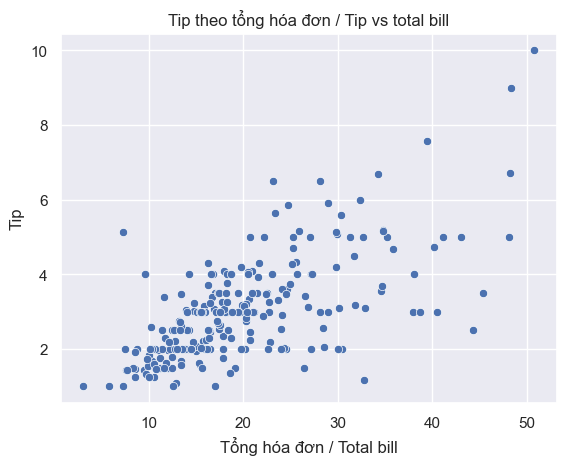

In [5]:
sns.scatterplot(data=tips, x="total_bill", y="tip")
plt.title("Tip theo tổng hóa đơn / Tip vs total bill")
plt.xlabel("Tổng hóa đơn / Total bill")
plt.ylabel("Tip")
plt.show()


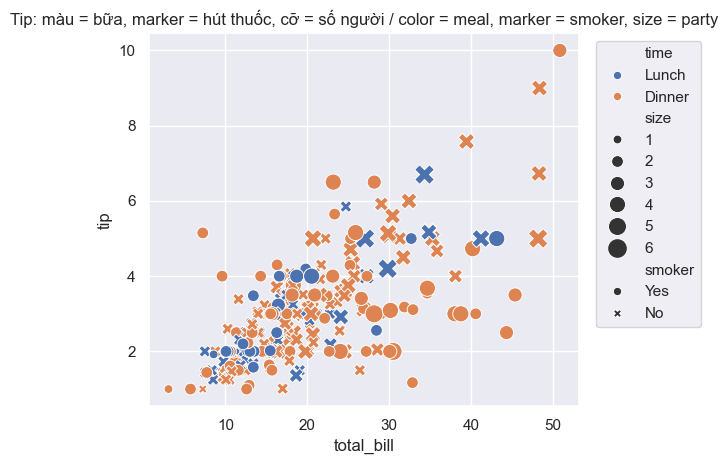

In [6]:
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="time",
    style="smoker",
    size="size",
    sizes=(40, 200),
)
plt.title("Tip: màu = bữa, marker = hút thuốc, cỡ = số người / color = meal, marker = smoker, size = party")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


So với Matplotlib: không cần lọc `tips[tips["time"]=="Lunch"]` rồi vẽ hai lần — chỉ cần `hue="time"`.

Compared with Matplotlib, you do not filter `tips[tips["time"]=="Lunch"]` and plot twice — pass `hue="time"` instead.


### Line — xu hướng theo thứ tự / trends in order

Dùng `flights`: số khách theo tháng/năm.

Use `flights`: passengers by month and year.


In [7]:
flights = sns.load_dataset("flights")
flights.head()


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


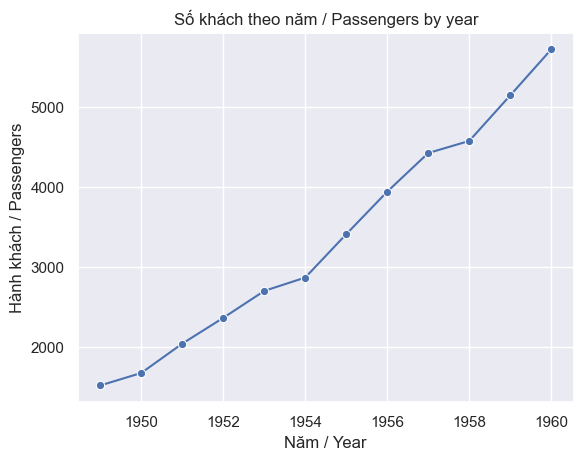

In [8]:
# Tổng khách mỗi năm / Passengers per year
theo_nam = flights.groupby("year", as_index=False)["passengers"].sum()

sns.lineplot(data=theo_nam, x="year", y="passengers", marker="o")
plt.title("Số khách theo năm / Passengers by year")
plt.xlabel("Năm / Year")
plt.ylabel("Hành khách / Passengers")
plt.show()


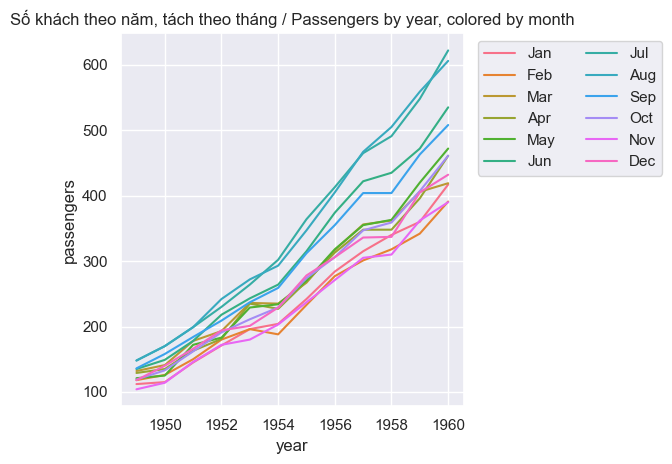

In [9]:
# Nhiều đường: mỗi tháng một màu / One line per month
sns.lineplot(data=flights, x="year", y="passengers", hue="month")
plt.title("Số khách theo năm, tách theo tháng / Passengers by year, colored by month")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2)
plt.tight_layout()
plt.show()


`sns.lineplot` mặc định vẽ **trung bình** và **khoảng tin cậy 95%** nếu một `x` có nhiều giá trị `y`. Muốn tắt dải bóng: `errorbar=None`.

By default `sns.lineplot` draws the **mean** and a **95% confidence interval** when one `x` has many `y` values. Turn the band off with `errorbar=None`.


## 4. Bar và count / Bar and count <a id="bar"></a>

* `barplot`: trục y là **số** — mặc định vẽ **trung bình** và vạch sai số
* `countplot`: đếm **số dòng** theo danh mục (không cần cột y)

* `barplot`: numeric `y` — by default the **mean** plus an error bar
* `countplot`: counts **rows** per category (no `y` column needed)


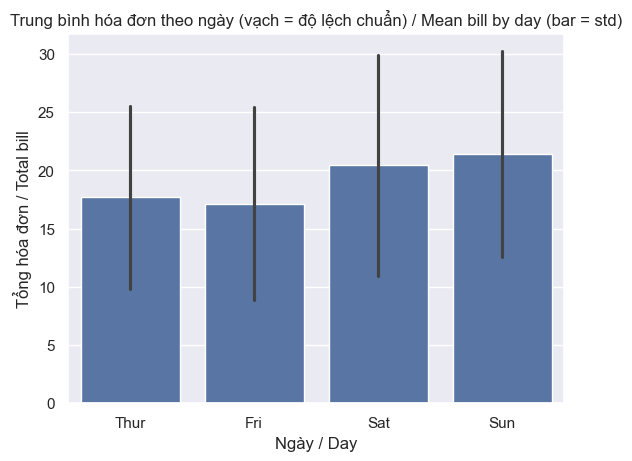

In [10]:
sns.barplot(data=tips, x="day", y="total_bill", estimator="mean", errorbar="sd")
plt.title("Trung bình hóa đơn theo ngày (vạch = độ lệch chuẩn) / Mean bill by day (bar = std)")
plt.xlabel("Ngày / Day")
plt.ylabel("Tổng hóa đơn / Total bill")
plt.show()


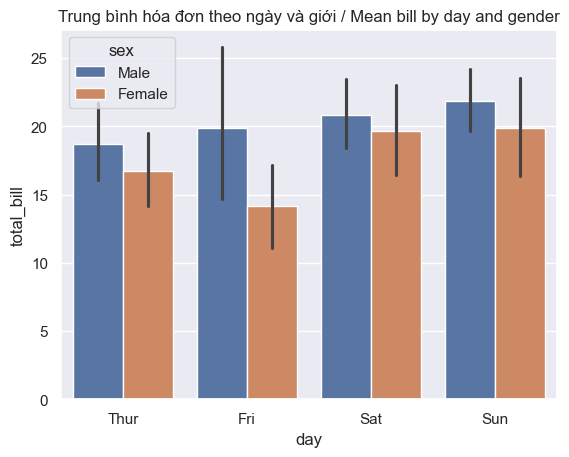

In [11]:
sns.barplot(data=tips, x="day", y="total_bill", hue="sex")
plt.title("Trung bình hóa đơn theo ngày và giới / Mean bill by day and gender")
plt.show()


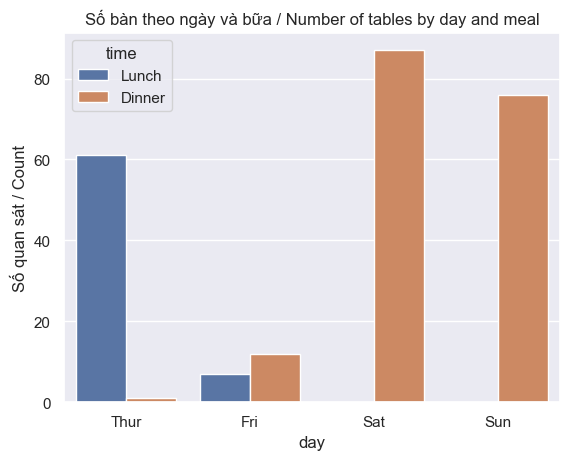

In [12]:
sns.countplot(data=tips, x="day", hue="time")
plt.title("Số bàn theo ngày và bữa / Number of tables by day and meal")
plt.ylabel("Số quan sát / Count")
plt.show()


`barplot` **không** vẽ tổng từng nhóm trừ khi bạn `groupby` trước, hoặc đổi `estimator="sum"`.

`barplot` does **not** show group totals unless you aggregate first or set `estimator="sum"`.


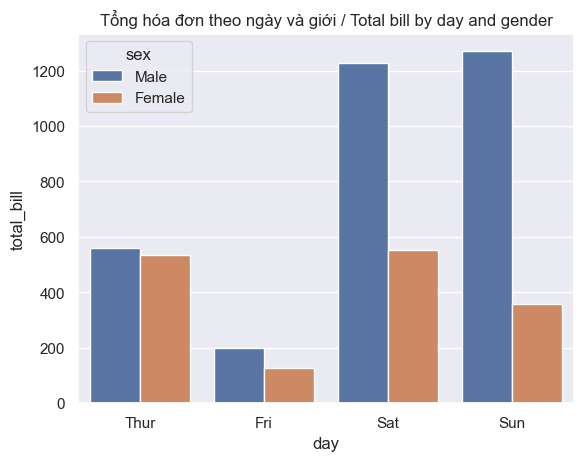

In [13]:
sns.barplot(data=tips, x="day", y="total_bill", hue="sex", estimator="sum", errorbar=None)
plt.title("Tổng hóa đơn theo ngày và giới / Total bill by day and gender")
plt.show()


## 5. Phân phối / Distributions: hist, kde, box, violin <a id="phan-phoi"></a>

### Histogram và KDE / Histogram and KDE


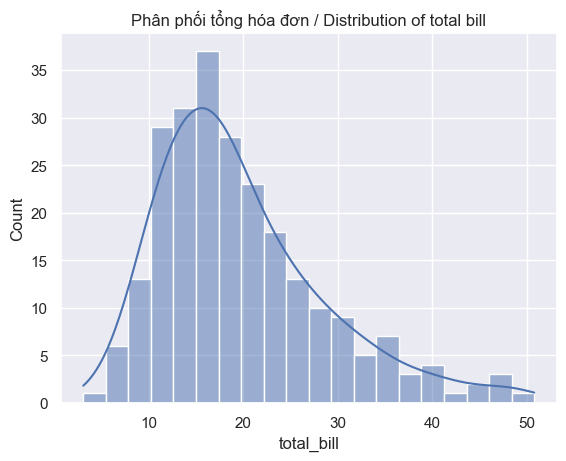

In [14]:
sns.histplot(data=tips, x="total_bill", bins=20, kde=True)
plt.title("Phân phối tổng hóa đơn / Distribution of total bill")
plt.show()


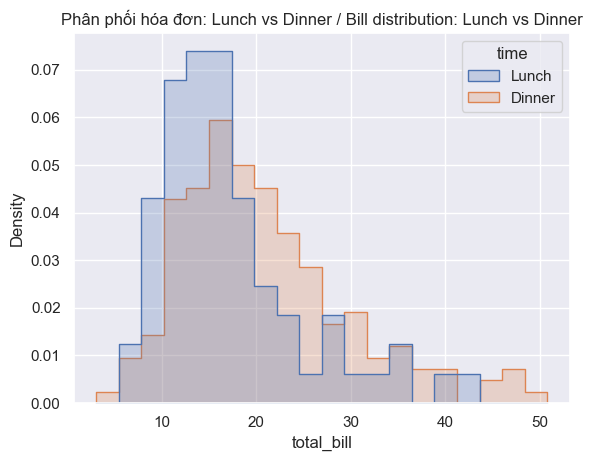

In [15]:
sns.histplot(data=tips, x="total_bill", hue="time", bins=20, element="step", stat="density", common_norm=False)
plt.title("Phân phối hóa đơn: Lunch vs Dinner / Bill distribution: Lunch vs Dinner")
plt.show()


`kdeplot` vẽ mật độ mượt, không chia cột.

`kdeplot` draws a smooth density curve with no bins.


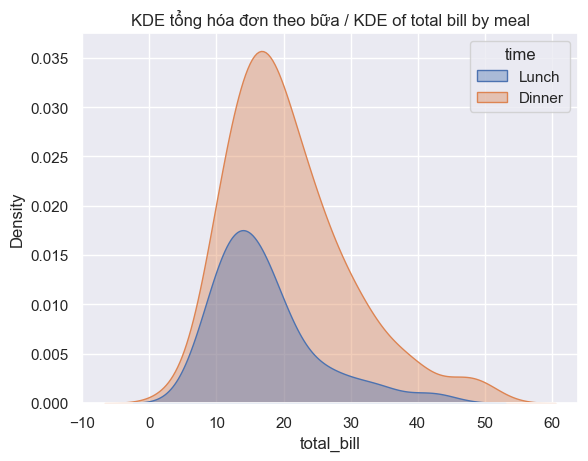

In [16]:
sns.kdeplot(data=tips, x="total_bill", hue="time", fill=True, alpha=0.4)
plt.title("KDE tổng hóa đơn theo bữa / KDE of total bill by meal")
plt.show()


### Boxplot và violin / Box plot and violin plot

* **Box**: trung vị, tứ phân vị, điểm ngoại lai / median, quartiles, outliers
* **Violin**: hình dạng phân phối (KDE đối xứng) + box bên trong / distribution shape (mirrored KDE) plus an inner box


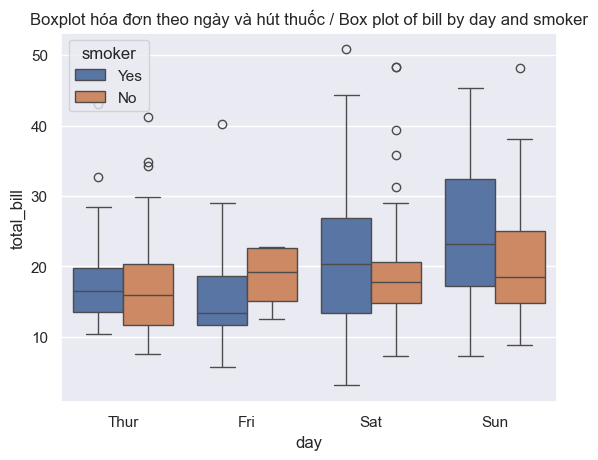

In [17]:
sns.boxplot(data=tips, x="day", y="total_bill", hue="smoker")
plt.title("Boxplot hóa đơn theo ngày và hút thuốc / Box plot of bill by day and smoker")
plt.show()


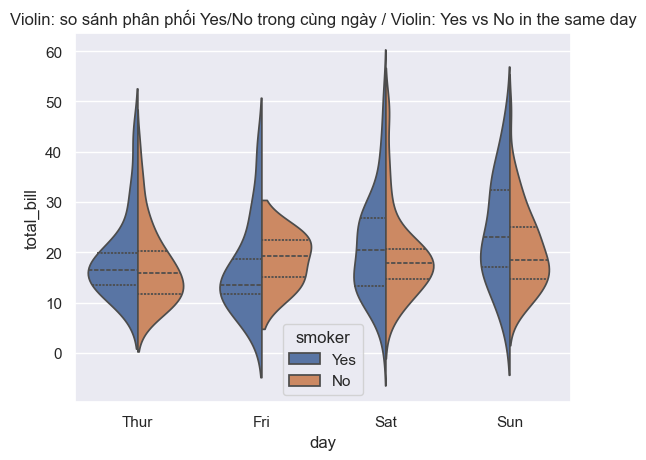

In [18]:
sns.violinplot(data=tips, x="day", y="total_bill", hue="smoker", split=True, inner="quartile")
plt.title("Violin: so sánh phân phối Yes/No trong cùng ngày / Violin: Yes vs No in the same day")
plt.show()


## 6. Heatmap <a id="heatmap"></a>

Heatmap tô màu ma trận. Hay dùng cho **tương quan** hoặc bảng pivot (tháng × năm).

A heatmap colors a matrix. Typical uses are a **correlation** matrix or a pivot table (month × year).


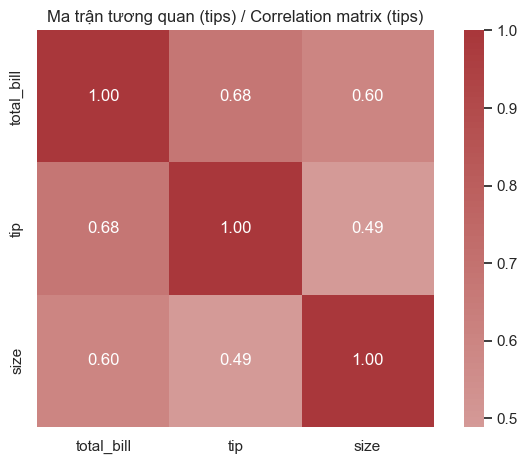

In [19]:
so = tips.select_dtypes(include="number")
corr = so.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Ma trận tương quan (tips) / Correlation matrix (tips)")
plt.tight_layout()
plt.show()


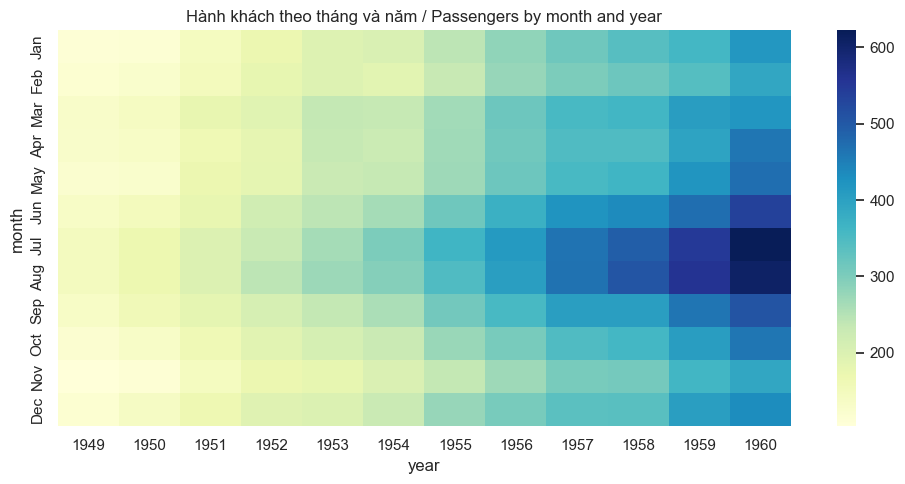

In [20]:
bang = flights.pivot(index="month", columns="year", values="passengers")

plt.figure(figsize=(10, 5))
sns.heatmap(bang, cmap="YlGnBu", annot=False)
plt.title("Hành khách theo tháng và năm / Passengers by month and year")
plt.tight_layout()
plt.show()


## 7. Nhiều hình: relplot và catplot / Facets: relplot and catplot <a id="facet"></a>

Thay vì `plt.subplots` rồi lọc dữ liệu từng ô:

Instead of `plt.subplots` and filtering each panel:

* `relplot`: scatter / line, tách theo `col`, `row` / split by `col`, `row`
* `catplot`: bar / box / violin / count, cùng cách tách / same splitting

Chúng trả về `FacetGrid` (không phải `Axes`). Đặt title chung: `g.fig.suptitle(...)`.

They return a `FacetGrid` (not an `Axes`). Set a shared title with `g.fig.suptitle(...)`.


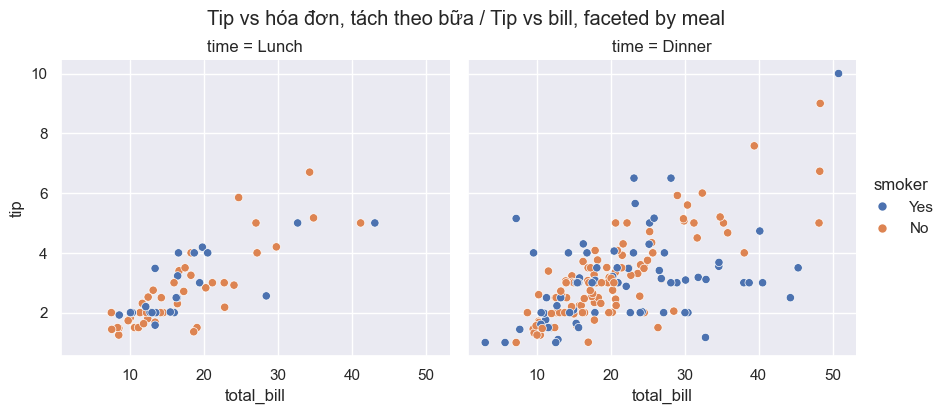

In [21]:
g = sns.relplot(
    data=tips,
    kind="scatter",
    x="total_bill",
    y="tip",
    hue="smoker",
    col="time",
    height=4,
    aspect=1.1,
)
g.fig.suptitle("Tip vs hóa đơn, tách theo bữa / Tip vs bill, faceted by meal", y=1.03)
plt.show()


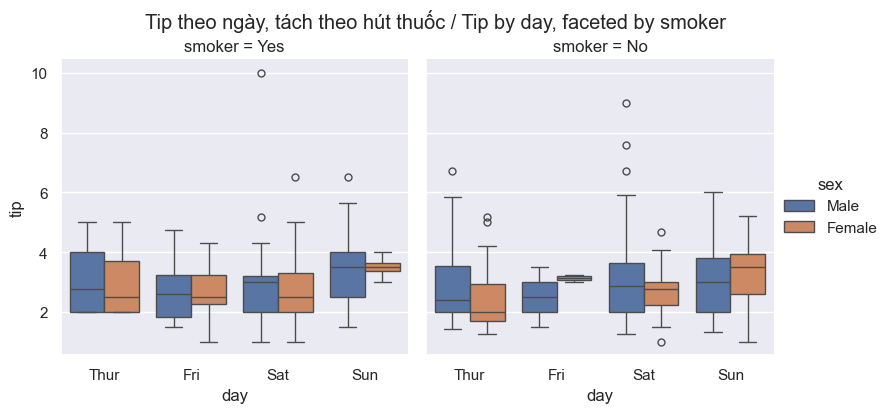

In [22]:
g = sns.catplot(
    data=tips,
    kind="box",
    x="day",
    y="tip",
    hue="sex",
    col="smoker",
    height=4,
    aspect=1.0,
)
g.fig.suptitle("Tip theo ngày, tách theo hút thuốc / Tip by day, faceted by smoker", y=1.03)
plt.show()


## 8. Pairplot <a id="pairplot"></a>

`pairplot` vẽ mọi cặp biến số: đường chéo là phân phối, ô khác là scatter. Hữu ích khi mới mở dataset.

`pairplot` draws every pair of numeric columns: distributions on the diagonal, scatter plots elsewhere. Useful when you first open a dataset.


In [23]:
iris = sns.load_dataset("iris")
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


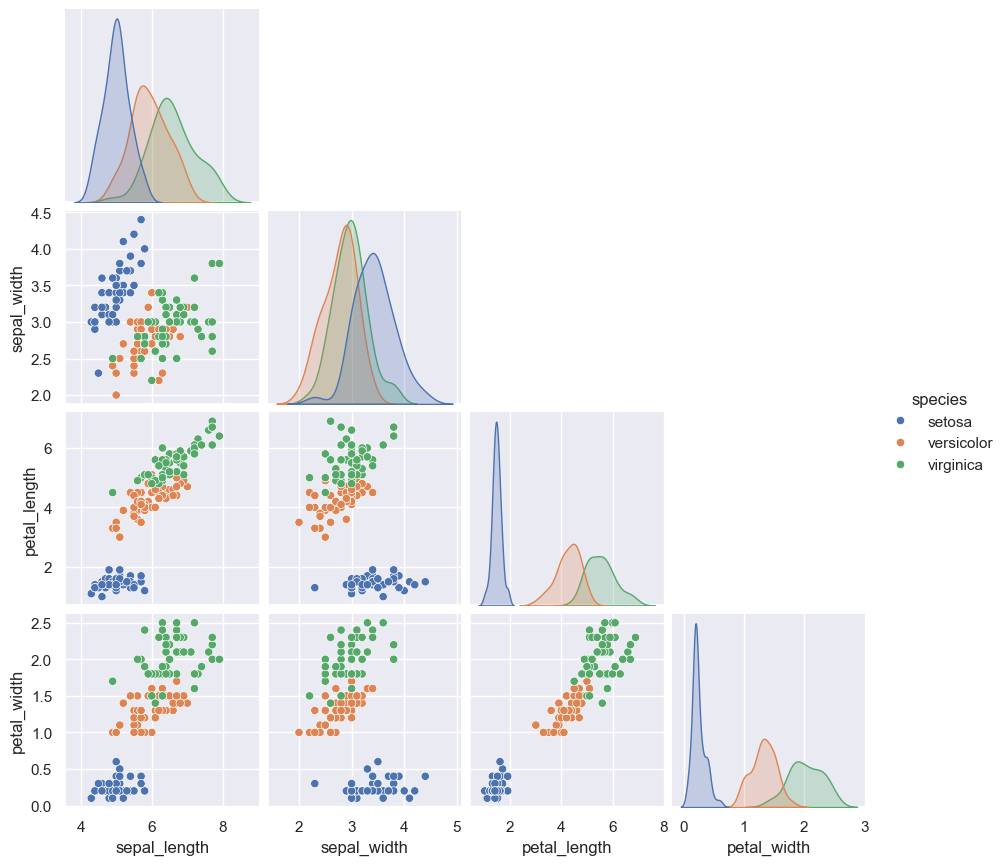

In [24]:
sns.pairplot(iris, hue="species", corner=True, height=2.2)
plt.show()


## 9. Kết hợp với Matplotlib / Combining with Matplotlib <a id="ket-hop"></a>

Hàm mức axes (`scatterplot`, `barplot`, `heatmap`, …) nhận `ax=`. Dùng khi ghép nhiều loại hình trên một figure.

Axes-level functions (`scatterplot`, `barplot`, `heatmap`, …) accept `ax=`. Use that when you combine several chart types on one figure.


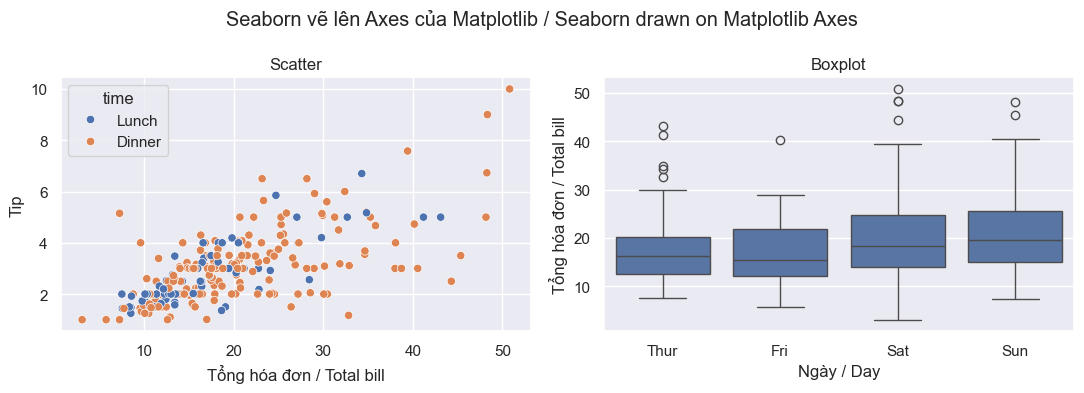

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.scatterplot(data=tips, x="total_bill", y="tip", hue="time", ax=axes[0])
axes[0].set_title("Scatter")
axes[0].set_xlabel("Tổng hóa đơn / Total bill")
axes[0].set_ylabel("Tip")

sns.boxplot(data=tips, x="day", y="total_bill", ax=axes[1])
axes[1].set_title("Boxplot")
axes[1].set_xlabel("Ngày / Day")
axes[1].set_ylabel("Tổng hóa đơn / Total bill")

fig.suptitle("Seaborn vẽ lên Axes của Matplotlib / Seaborn drawn on Matplotlib Axes")
fig.tight_layout()
plt.show()


**Lưu ý:** `relplot` / `catplot` / `pairplot` tự tạo figure mới — **không** truyền `ax=`. Muốn gán vào subplot có sẵn, dùng `scatterplot`, `lineplot`, `boxplot`, …

**Note:** `relplot` / `catplot` / `pairplot` create a new figure — do **not** pass `ax=`. To fill an existing subplot, use `scatterplot`, `lineplot`, `boxplot`, …


## 10. Tóm tắt / Summary <a id="tom-tat"></a>

| Nhu cầu / Need | Hàm Seaborn / Function |
|---|---|
| Quan hệ 2 biến số / Two numeric variables | `scatterplot`, `lineplot` |
| So sánh trung bình / tổng theo nhóm / Mean or total by group | `barplot` (`estimator`) |
| Đếm danh mục / Count categories | `countplot` |
| Phân phối / Distribution | `histplot`, `kdeplot` |
| Trung vị và ngoại lai / Median and outliers | `boxplot` |
| Hình dạng phân phối theo nhóm / Shape by group | `violinplot` |
| Ma trận / tương quan / Matrix / correlation | `heatmap` |
| Tách nhiều hình theo cột / Split into panels | `relplot`, `catplot` |
| Mọi cặp biến / Every pair of variables | `pairplot` |

**Gợi ý / Practice tips**

1. Có DataFrame và muốn tô màu theo nhóm → Seaborn (`hue`, `col`).
   Have a DataFrame and want color by group → Seaborn (`hue`, `col`).
2. Cần chỉnh từng pixel, nhiều loại hình trên một lưới → Matplotlib `ax`, hoặc `ax=` cho hàm Seaborn mức axes.
   Need pixel-level control or mixed chart types on one grid → Matplotlib `ax`, or `ax=` on axes-level Seaborn functions.
3. `set_theme` / `style.use` phải chạy **trước** khi vẽ; hình Jupyter cũ không tự đổi.
   `set_theme` / `style.use` must run **before** plotting; old Jupyter figures do not update.
4. `barplot` mặc định là **trung bình**, không phải tổng hay count.
   `barplot` defaults to the **mean**, not a sum or a count.

Đổi `hue`, `bins`, `kind`, hoặc `col` rồi chạy lại cell để thấy biểu đồ thay đổi.

Change `hue`, `bins`, `kind`, or `col` and re-run the cell to see how the plot responds.

Hướng dẫn **nhìn hình và viết nhận xét** (hue, dải CI, box, violin, heatmap, facet): `w3_5_How-to-Read-Seaborn.ipynb`.

For **how to read** these plots and write comments, see `w3_5_How-to-Read-Seaborn.ipynb`.
